## PROYECTO 2: EXPLORATORY DATA ANALYSIS (EDA)

## "Impacto de la violencia armada en la población civil"

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from plotly.offline import iplot
from matplotlib.ticker import FuncFormatter

import sys
import os
sys.path.append(os.path.abspath(".."))
from utils import funciones as fc
from utils import datasets_limpios as dt

## DATASETS:

DATASETS ACNUR

In [4]:
# 1. País acogida
dt.df_ACNUR_pais_acogida

,País/Territorio de asilo,Refugiadas,Solicitantes de asilo (casos pendientes),Otras personas que necesitan protección internacional,Desplazadas internas,Apátridas,Otras personas de interés
0,Afghanistan,34826,250,0,3222397,0,33712
1,Albania,5079,8,0,0,2018,6
2,Algeria,98590,3601,0,0,0,0
3,Angola,25174,30268,0,0,0,199
4,Argentina,4104,7129,215541,0,22,475
...,...,...,...,...,...,...,...
174,Western Sahara,0,0,0,0,0,0
175,Yemen,55568,15259,0,4516341,0,15
176,Zambia,72411,5549,0,0,0,17550
177,Zimbabwe,10114,12451,0,0,0,1003


In [5]:
# 2. Oficinas ACNUR, país de acogida
dt.df_ACNUR_pais_acogida_UNHCR_bureaus

,Oficinas ACNUR,Refugiadas,Solicitantes de asilo (casos pendientes),Otras personas que necesitan protección internacional,Desplazadas internas,Apátridas,Otras personas de interés
0,"East and Horn of Africa, and Great Lakes",4830730,382742,0,16719267,97591,90080
1,Southern Africa,806729,186170,0,6834554,0,32871
2,West and Central Africa,2122973,177075,0,7887599,931093,160325
3,Sub-Saharan Africa,7760432,745987,0,31441420,1028684,283276
4,Americas,1086566,3954551,5755363,7813275,7339,4395196
5,Asia and the Pacific,7432455,271573,0,6039085,2504784,220478
6,Europe,13061135,1449236,0,4943593,493835,972075
7,Middle East and North Africa,2296820,437152,0,13013994,323546,74525
8,Various/Stateless,0,0,0,0,0,0


In [6]:
# 3. Regiones ONU, país de acogida
dt.df_ACNUR_pais_acogida_UN_regions

,Regiones ONU,Refugiadas,Solicitantes de asilo (casos pendientes),Otras personas que necesitan protección internacional,Desplazadas internas,Apátridas,Otras personas de interés
0,Africa,8226204,1065029,0,31567222,1028694,283299
1,Asia,12688667,557470,0,19784857,2822282,291730
2,Europe,9589094,1193669,0,3990013,491771,972075
3,Latin America,503797,1119390,5572863,7499374,2117,4393191
4,North America and the Caribbean,582769,2835161,182500,313901,5222,2005
5,Oceania,46877,87780,0,96000,8102,3250
6,Various/Stateless,0,0,0,0,0,0


In [7]:
# 4. País origen
dt.df_ACNUR_pais_origen

,Origen,Refugiadas,Solicitantes de asilo (casos pendientes),Otras personas que necesitan protección internacional,Desplazadas internas,Apátridas,Otras personas de interés
0,Afghanistan,6403144,296033,0,3222397,0,34534
1,Albania,21919,17539,0,0,0,0
2,Algeria,7629,11330,0,0,0,48
3,Andorra,0,14,0,0,0,0
4,Angola,11506,22824,0,0,0,13637
...,...,...,...,...,...,...,...
200,Yemen,48044,33521,0,4516341,0,24
201,Zambia,324,628,0,0,0,5
202,Zimbabwe,7460,9125,0,0,0,170
203,Stateless,51912,5344,0,0,4358188,8998


In [8]:
# 5. Oficinas ACNUR, país de origen
dt.df_ACNUR_pais_origen_UNHCR_bureaus

,Oficinas ACNUR,Refugiadas,Solicitantes de asilo (casos pendientes),Otras personas que necesitan protección internacional,Desplazadas internas,Apátridas,Otras personas de interés
0,"East and Horn of Africa, and Great Lakes",5938613,816828,0,16719267,0,98247
1,Southern Africa,1016630,212366,0,6834554,0,32520
2,West and Central Africa,1741882,417331,0,7887599,0,163030
3,Sub-Saharan Africa,8697125,1446525,0,31441420,0,293797
4,Americas,861514,3330751,5755363,7813275,0,4228532
5,Asia and the Pacific,8385982,993931,0,6039085,0,220212
6,Europe,6481525,431625,0,4943593,0,990198
7,Middle East and North Africa,6980098,554773,0,13013994,0,38006
8,Various/Stateless,231164,100894,0,0,4358188,174805


In [9]:
# 6. Regiones ONU, país de origen
dt.df_ACNUR_pais_origen_UN_regions

,Regiones ONU,Refugiadas,Solicitantes de asilo (casos pendientes),Otras personas que necesitan protección internacional,Desplazadas internas,Apátridas,Otras personas de interés
0,Africa,8886005,1556386,0,31567222,0,295036
1,Asia,15491965,1648897,0,19784857,0,255718
2,Europe,6165917,214734,0,3990013,0,989723
3,Latin America,732321,3076179,5755363,7499374,0,4190473
4,North America and the Caribbean,129193,254572,0,313901,0,38059
5,Oceania,843,6837,0,96000,0,1736
6,Various/Stateless,231164,100894,0,0,4358188,174805


In [10]:
# 7. demografía
dt.df_ACNUR_demografia

,Edad,Sexo,Refugiadas,Solicitantes de asilo,Otras personas que necesitan protección internacional,Desplazadas internas,Apátridas,Otras personas de interés,Refugiadas retornadas,Desplazadas internas retornadas
0,0-4,M,1425602,89810,115318,2024378,155147,111644,13932,36670
1,5-11,M,2444869,132867,66785,3243605,149007,168545,23327,38227
2,12-17,M,1699112,90942,372028,2536557,108118,267976,8738,45274
4,18-59,M,5776545,554277,1396637,8928840,563177,1261576,30131,156388
5,60+,M,592012,35671,84065,1706046,70095,9143,1885,31673
6,Unknown age,M,1061321,189956,607315,2692038,56528,218917,10,113855
8,0-4,H,1462354,91878,120840,2053130,159690,109369,13493,42254
9,5-11,H,2499162,138862,73851,3572154,171445,161349,22223,46471
10,12-17,H,1768560,113041,371510,2725109,104035,233737,8133,41806
12,18-59,H,5858297,840179,1288318,8102253,463447,1016272,26442,130022


DATASET UCDP

In [11]:
dt.df_UCDP_conflictos

,ID conflicto,Ubicación,Incompatibilidad,Nombre territorio,Año,Nivel intensidad,Región
0,11342,India,Territorio,Garoland,2012,Menor (25-99 muertes),Asia
1,11342,India,Territorio,Garoland,2014,Menor (25-99 muertes),Asia
2,11343,"Egypt, Israel",Territorio,Suez/Sinai,1967,Guerra (>1000 muertes),Oriente Próximo
3,11343,"Egypt, Israel",Territorio,Suez/Sinai,1969,Menor (25-99 muertes),Oriente Próximo
4,11343,"Egypt, Israel",Territorio,Suez/Sinai,1970,Menor (25-99 muertes),Oriente Próximo
...,...,...,...,...,...,...,...
2747,440,Myanmar (Burma),Territorio,Lahu,1979,Menor (25-99 muertes),Asia
2748,440,Myanmar (Burma),Territorio,Lahu,1980,Menor (25-99 muertes),Asia
2749,440,Myanmar (Burma),Territorio,Lahu,1981,Menor (25-99 muertes),Asia
2750,440,Myanmar (Burma),Territorio,Lahu,1982,Menor (25-99 muertes),Asia


DATASET SVAC

In [12]:
dt.df_SVAC_violencia_sexual

,Año,ID conflicto,ID actor,Tipo actor,Incompatibilidad,Región,Ubicación,Conflicto (dummy),Datos EEUU,Datos Amnistía Internacional,Datos Human Rights Watch,Datos ¿?,Forma violencia
0,1989,205,114,Estado/Gobierno,Territorio,Oriente Próximo,Iran,Otro,Ninguna,Ninguna,Ninguna,Ninguna,No reporte y No datos
1,1990,205,114,Estado/Gobierno,Territorio,Oriente Próximo,Iran,Conflicto,Ninguna,Ninguna,Ninguna,Ninguna,No reporte y No datos
2,1991,205,114,Estado/Gobierno,Territorio,Oriente Próximo,Iran,Otro,Ninguna,Ninguna,Ninguna,Ninguna,No reporte y No datos
3,1992,205,114,Estado/Gobierno,Territorio,Oriente Próximo,Iran,Otro,Ninguna,Ninguna,Ninguna,Ninguna,No reporte y No datos
4,1993,205,114,Estado/Gobierno,Territorio,Oriente Próximo,Iran,Conflicto,Ninguna,Ninguna,Ninguna,Ninguna,No reporte y No datos
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12831,2023,15283,86,Estado/Gobierno,Territorio,África,Central African Republic,Conflicto,Aislada,Ninguna,Ninguna,Ninguna,Violación
12845,2023,15283,6354,Rebeldes,Territorio,África,Central African Republic,Conflicto,Aislada,Ninguna,Ninguna,Ninguna,Violación
12869,2023,16038,72,Estado/Gobierno,Territorio y gobierno,África,Mali,Conflicto,Aislada,Ninguna,Ninguna,Ninguna,Violación
12870,2023,16069,97,Estado/Gobierno,Territorio y gobierno,África,Ethiopia,Conflicto,Ninguna,Ninguna,Aislada,Aislada,Violación


DATASET ACLED

In [13]:
dt.df_ACLED_ataques_y_muertes

,País,Año,Ataques a civiles,Muertes de civiles,Muertes totales
0,Afghanistan,2023,625,462,1152
1,Albania,2023,5,1,1
2,Algeria,2023,10,11,13
3,Angola,2023,55,47,66
4,Anguilla,2023,1,0,0
...,...,...,...,...,...
158,Vietnam,2023,2,1,11
159,Yemen,2023,1239,760,2664
160,Zambia,2023,29,15,15
161,Zimbabwe,2023,160,40,40


NUEVO : DATASET ACNUR (4. País Origen) + ACLED

In [14]:
dt.df_merged_ACNURor_ACLED

,Origen,Refugiadas,Solicitantes de asilo (casos pendientes),Otras personas que necesitan protección internacional,Desplazadas internas,Apátridas,Otras personas de interés,Total,Ataques a civiles,Muertes de civiles,Muertes totales
0,Afghanistan,6403144,296033,0,3222397,0,34534,9921574,625,462,1152
1,Albania,21919,17539,0,0,0,0,39458,5,1,1
2,Algeria,7629,11330,0,0,0,48,18959,10,11,13
3,Angola,11506,22824,0,0,0,13637,34330,55,47,66
4,Anguilla,0,5,0,0,0,0,5,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
153,Venezuela,347695,1200130,5755363,0,0,3293301,7303188,278,254,783
154,Vietnam,18339,13179,0,0,0,68,31518,2,1,11
155,Yemen,48044,33521,0,4516341,0,24,4597906,1239,760,2664
156,Zambia,324,628,0,0,0,5,952,29,15,15


## HIPÓTESIS 1

Hipótesis 1: En 2023, los países en conflicto armado reportaron mayores niveles de desplazamiento forzado.

In [15]:
# Añadir columna de total y ordenar de mayor a menor número de personas desplazadas
dt.df_ACNUR_pais_origen.insert(7, "Total", dt.df_ACNUR_pais_origen[["Refugiadas", "Solicitantes de asilo (casos pendientes)", "Otras personas que necesitan protección internacional", "Desplazadas internas", "Apátridas"]].sum(axis=1))
dt.df_ACNUR_pais_origen = dt.df_ACNUR_pais_origen.sort_values("Total", ascending=False)
# Añadir una columna con TRUE si esos países tenían conflicto en 2023 y FALSE si no, usando UCDP como referencia
dt.df_ACNUR_pais_origen["En conflicto"] = dt.df_ACNUR_pais_origen["Origen"].isin(fc.paises_conflicto)

In [16]:
# Comprobar el porcentaje de países en conflicto para países en el top25 con más personas desplazadas
head25 = dt.df_ACNUR_pais_origen.head(25)
count = head25["En conflicto"].sum()
total = len(head25)
porcentaje = count / total * 100

print(f"Países en conflicto del top25 con más personas desplazadas: {count} ({porcentaje:.1f}%)")
print(f"Países no en conflicto del top25 con más personas desplazadas: {total - count} ({100 - porcentaje:.1f}%)")

Países en conflicto del top25 con más personas desplazadas: 18 (72.0%)
Países no en conflicto del top25 con más personas desplazadas: 7 (28.0%)


In [17]:
# Comprobar el porcentaje de países en conflicto para países con más de 100.000 personas desplazadas
desplazados_100000 = dt.df_ACNUR_pais_origen[dt.df_ACNUR_pais_origen["Total"] > 100000]
count = desplazados_100000["En conflicto"].sum()
total = len(desplazados_100000)
porcentaje = count / total * 100

print(f"Países en conflicto con más personas de 100.000 personas desplazadas: {count} ({porcentaje:.1f}%)")
print(f"Países no en conflicto con más personas de 100.000 personas desplazadas: {total - count} ({100 - porcentaje:.1f}%)")

Países en conflicto con más personas de 100.000 personas desplazadas: 28 (60.9%)
Países no en conflicto con más personas de 100.000 personas desplazadas: 18 (39.1%)


In [18]:
# Mapas en DataWrapper

## HIPÓTESIS 2

Hipótesis 2: En 2023, los principales países de acogida de personas desplazadas también experimentaron al menos un conflicto armado activo.

In [19]:
# Añadir columna de total y ordenar de mayor a menor número de personas acogidas
dt.df_ACNUR_pais_acogida.insert(7, "Total", dt.df_ACNUR_pais_acogida[["Refugiadas", "Solicitantes de asilo (casos pendientes)", "Otras personas que necesitan protección internacional", "Desplazadas internas", "Apátridas"]].sum(axis=1))
dt.df_ACNUR_pais_acogida = dt.df_ACNUR_pais_acogida.sort_values("Total", ascending=False)
# Añadir una columna con TRUE si esos países tenían conflicto en 2023 y FALSE si no, usando UCDP como referencia
dt.df_ACNUR_pais_acogida["En conflicto"] = dt.df_ACNUR_pais_acogida["País/Territorio de asilo"].isin(fc.paises_conflicto2)

In [20]:
# Comprobar el porcentaje de países en conflicto para el top25 con más personas acogidas
head25_2 = dt.df_ACNUR_pais_acogida.head(25)
count = head25_2["En conflicto"].sum()
total = len(head25_2)
porcentaje = count / total * 100

print(f"Países en conflicto del top25 con más personas acogidas: {count} ({porcentaje:.1f}%)")
print(f"Países no en conflicto del top25 con más personas desplazadas: {total - count} ({100 - porcentaje:.1f}%)")

Países en conflicto del top25 con más personas acogidas: 19 (76.0%)
Países no en conflicto del top25 con más personas desplazadas: 6 (24.0%)


In [21]:
# Comprobar el porcentaje de países en conflicto para países con más de 100.000 personas acogidas
desplazados_100000_2 = dt.df_ACNUR_pais_acogida[dt.df_ACNUR_pais_acogida["Total"] > 100000]
count = desplazados_100000_2["En conflicto"].sum()
total = len(desplazados_100000_2)
porcentaje = count / total * 100

print(f"Países en conflicto con más personas de 100.000 personas acogidas: {count} ({porcentaje:.1f}%)")
print(f"Países no en conflicto con más personas de 100.000 personas acogidas: {total - count} ({100 - porcentaje:.1f}%)")

Países en conflicto con más personas de 100.000 personas acogidas: 29 (36.2%)
Países no en conflicto con más personas de 100.000 personas acogidas: 51 (63.8%)


In [22]:
# Mapas en DataWrapper

## HIPÓTESIS 3 Y 4

Hipótesis 3: A mayor ataques dirigidos contra civiles en conflictos armados, mayores niveles de desplazamiento forzado.  
Hipótesis 4: A mayores muertes de civiles o muertes totales en conflictos armados, mayores niveles de desplazamiento forzado.

In [23]:
# Estadísticos
pd.set_option('display.float_format', '{:.2f}'.format)
dt.df_merged_ACNURor_ACLED.describe()

,Refugiadas,Solicitantes de asilo (casos pendientes),Otras personas que necesitan protección internacional,Desplazadas internas,Apátridas,Otras personas de interés,Total,Ataques a civiles,Muertes de civiles,Muertes totales
count,158.00,158.00,158.00,158.00,158.00,158.00,158.00,158.00,158.00,158.00
mean,194319.33,41809.01,36426.35,400325.11,0.00,36469.63,672879.80,342.01,454.63,1262.30
std,885809.59,114929.13,457872.10,1358343.54,0.00,276307.25,2110538.23,858.35,1754.05,4467.91
min,0.00,5.00,0.00,0.00,0.00,0.00,5.00,1.00,0.00,0.00
25%,213.00,650.75,0.00,0.00,0.00,0.00,1057.25,5.00,1.00,1.00
50%,2497.00,5762.50,0.00,0.00,0.00,5.00,12089.50,23.00,6.00,10.00
75%,22849.75,19123.50,0.00,0.00,0.00,230.00,162365.25,184.00,134.75,307.00
max,6403144.00,1200130.00,5755363.00,9052822.00,0.00,3293301.00,13786930.00,5235.00,19430.00,39776.00


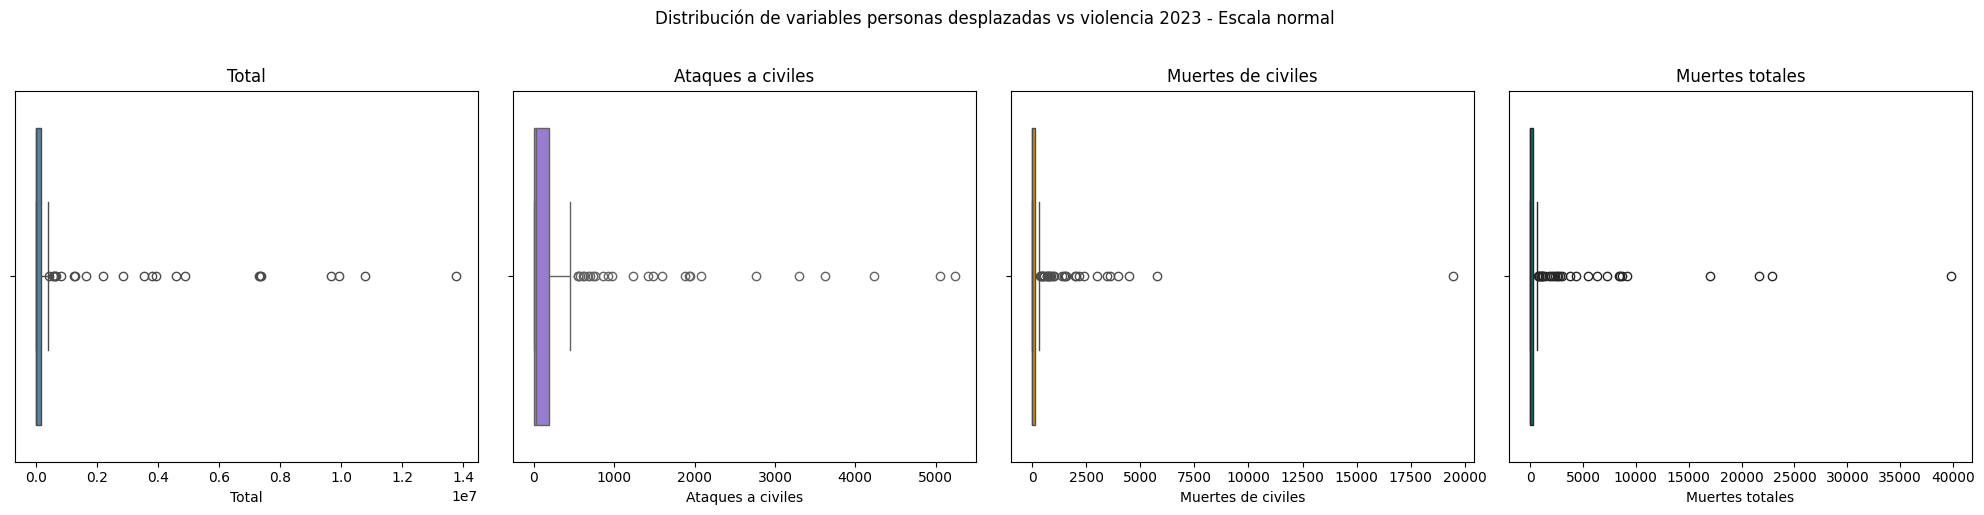

In [24]:
# Boxplot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

variables = ["Total", "Ataques a civiles", "Muertes de civiles", "Muertes totales"]
colores = ["steelblue", "mediumpurple", "darkorange", "teal"]

for ax, var, color in zip(axes, variables, colores):
    sns.boxplot(x=dt.df_merged_ACNURor_ACLED[var], color=color, ax=ax)
    ax.set_title(var)

plt.suptitle("Distribución de variables personas desplazadas vs violencia 2023 - Escala normal", y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Correlaciones
print(dt.df_merged_ACNURor_ACLED["Total"].corr(dt.df_merged_ACNURor_ACLED["Ataques a civiles"]))
print(dt.df_merged_ACNURor_ACLED["Total"].corr(dt.df_merged_ACNURor_ACLED["Muertes de civiles"]))
print(dt.df_merged_ACNURor_ACLED["Total"].corr(dt.df_merged_ACNURor_ACLED["Muertes totales"]))

0.4510433716218162
0.23516088783077346
0.5595398508761992


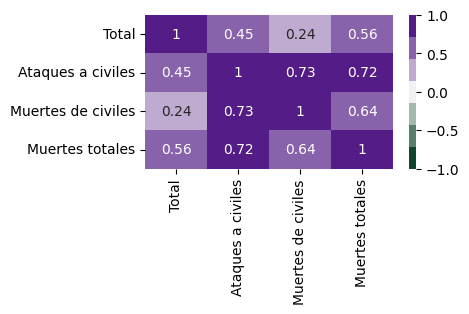

In [26]:
# Heatmap (correlaciones)
plt.figure(figsize=(4, 2))
sns.heatmap(dt.df_merged_ACNURor_ACLED[["Total", "Ataques a civiles", "Muertes de civiles", "Muertes totales"]].corr(), 
            annot = True, 
            vmin = -1, 
            vmax = 1,
            cmap=sns.diverging_palette(145, 280, s=85, l=25, n=7))
plt.show()

In [27]:
# Gráfica visual
import plotly.graph_objs as go

# creating trace1
trace1 = go.Scatter(
    x = dt.df_merged_ACNURor_ACLED["Total"],
    y = dt.df_merged_ACNURor_ACLED["Ataques a civiles"],
    mode = "markers",
    name = "Ataques a civiles",
    marker = dict(color = 'rgba(255, 128, 255, 0.8)'),
    text = dt.df_merged_ACNURor_ACLED["Origen"])

# creating trace2
trace2 = go.Scatter(
    x = dt.df_merged_ACNURor_ACLED["Total"],
    y = dt.df_merged_ACNURor_ACLED["Muertes de civiles"],
    mode = "markers",
    name = "Muertes de civiles",
    marker = dict(color = 'rgba(255, 128, 2, 0.8)'),
    text = dt.df_merged_ACNURor_ACLED["Origen"])

# creating trace3
trace3 = go.Scatter(
    x = dt.df_merged_ACNURor_ACLED["Total"],
    y = dt.df_merged_ACNURor_ACLED["Muertes totales"],
    mode = "markers",
    name = "Muertes totales",
    marker = dict(color = 'rgba(0, 255, 200, 0.8)'),
    text = dt.df_merged_ACNURor_ACLED["Origen"])

data = [trace1, trace2, trace3]

layout = dict(
    title = "Personas desplazadas vs Violencia armada/política por país en 2023 - Escala normal",
    xaxis = dict(title = "Total personas desplazadas", ticklen = 5, zeroline = False),
    yaxis = dict(title = "Número de ataques/muertes", ticklen = 5, zeroline = False)
)

fig = dict(data = data, layout = layout)
iplot(fig)

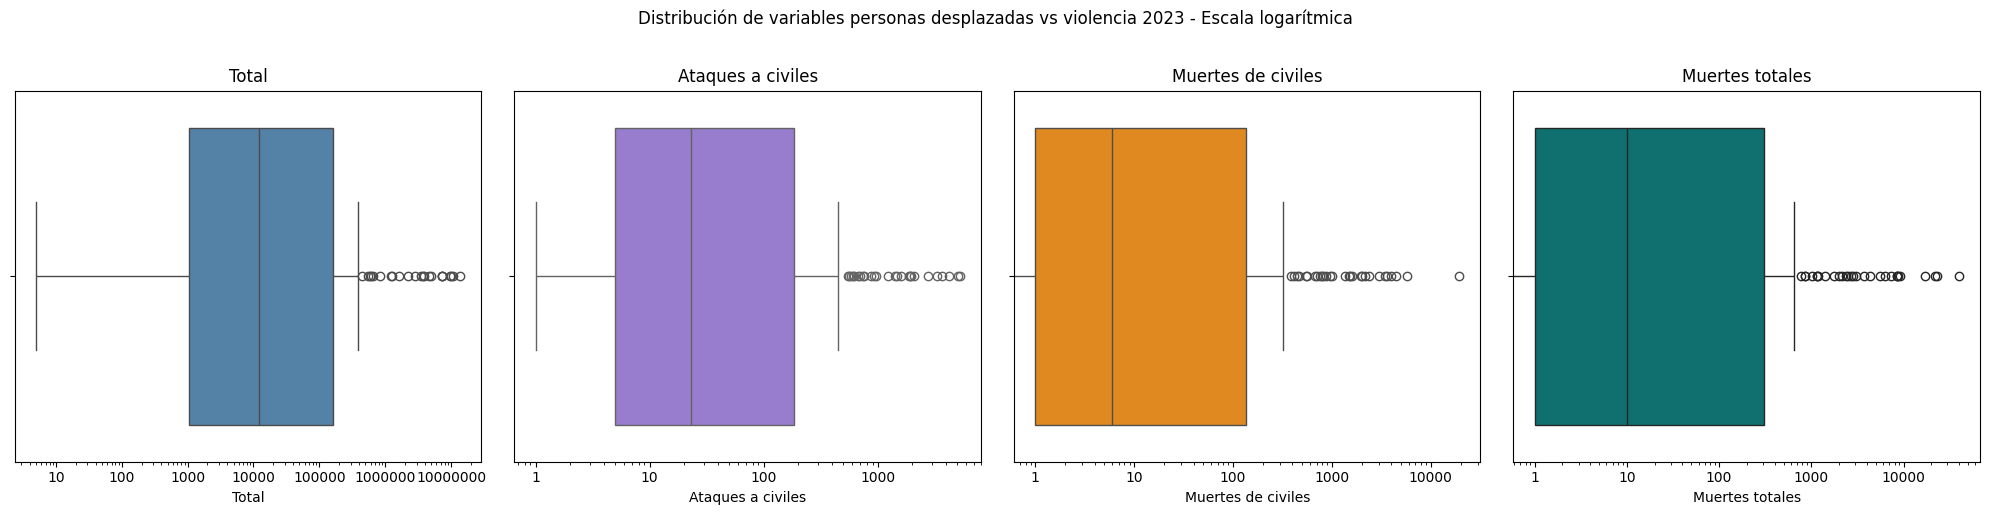

In [28]:
# Logarítmica
# Boxplot
from matplotlib.ticker import ScalarFormatter

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

variables = ["Total", "Ataques a civiles", "Muertes de civiles", "Muertes totales"]
colores = ["steelblue", "mediumpurple", "darkorange", "teal"]

for ax, var, color in zip(axes, variables, colores):
    sns.boxplot(x=dt.df_merged_ACNURor_ACLED[var], color=color, ax=ax)
    ax.set_title(var)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style="plain", axis="x")

plt.suptitle("Distribución de variables personas desplazadas vs violencia 2023 - Escala logarítmica", y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# Correlaciones
df_log = dt.df_merged_ACNURor_ACLED[["Total", "Ataques a civiles", "Muertes de civiles", "Muertes totales"]].copy()
df_log = df_log[df_log > 0].dropna()  # log no funciona con 0s
df_log = np.log(df_log)

print(df_log["Total"].corr(df_log["Ataques a civiles"]))
print(df_log["Total"].corr(df_log["Muertes de civiles"]))
print(df_log["Total"].corr(df_log["Muertes totales"]))

0.6332997357550454
0.6120405443806187
0.6756753530210761


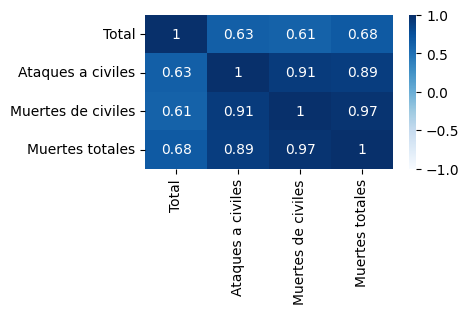

In [30]:
# Heatmap (correlaciones)
plt.figure(figsize=(4, 2))
sns.heatmap(df_log.corr(), 
            annot = True, 
            vmin = -1, 
            vmax = 1,
            cmap="Blues")
plt.show()

In [31]:
# # Gráfica visual
import plotly.graph_objs as go

# creating trace1
trace1 = go.Scatter(
    x = dt.df_merged_ACNURor_ACLED["Total"],
    y = dt.df_merged_ACNURor_ACLED["Ataques a civiles"],
    mode = "markers",
    name = "Ataques a civiles",
    marker = dict(color = 'rgba(255, 128, 255, 0.8)'),
    text = dt.df_merged_ACNURor_ACLED["Origen"])

# creating trace2
trace2 = go.Scatter(
    x = dt.df_merged_ACNURor_ACLED["Total"],
    y = dt.df_merged_ACNURor_ACLED["Muertes de civiles"],
    mode = "markers",
    name = "Muertes de civiles",
    marker = dict(color = 'rgba(255, 128, 2, 0.8)'),
    text = dt.df_merged_ACNURor_ACLED["Origen"])

# creating trace3
trace3 = go.Scatter(
    x = dt.df_merged_ACNURor_ACLED["Total"],
    y = dt.df_merged_ACNURor_ACLED["Muertes totales"],
    mode = "markers",
    name = "Muertes totales",
    marker = dict(color = 'rgba(0, 255, 200, 0.8)'),
    text = dt.df_merged_ACNURor_ACLED["Origen"])

data = [trace1, trace2, trace3]

layout = dict(
    title = "Personas desplazadas vs Violencia armada/política por país en 2023 - Escala logarítmica",
    xaxis = dict(title = "Total personas desplazadas", ticklen = 5, zeroline = False, type="log"),
    yaxis = dict(title = "Número de ataques/muertes", ticklen = 5, zeroline = False, type="log")
)

fig = dict(data = data, layout = layout)
iplot(fig)

In [32]:
# TOP 10 por variable
from plotly.subplots import make_subplots
import plotly.graph_objs as go

# Top 10 por cada variable
top10_total = dt.df_merged_ACNURor_ACLED.nlargest(10, "Total").sort_values("Total", ascending=False)
top10_ataques = dt.df_merged_ACNURor_ACLED.nlargest(10, "Ataques a civiles").sort_values("Ataques a civiles", ascending=False)
top10_muertes_civiles = dt.df_merged_ACNURor_ACLED.nlargest(10, "Muertes de civiles").sort_values("Muertes de civiles", ascending=False)
top10_muertes = dt.df_merged_ACNURor_ACLED.nlargest(10, "Muertes totales").sort_values("Muertes totales", ascending=False)

xaxis_config = dict(tickangle=-25, tickfont=dict(size=9))

# Gráfica 1
fig1 = go.Figure(data=[
    go.Bar(name="Ataques a civiles", x=top10_total["Origen"], y=top10_total["Ataques a civiles"], marker_color="rgba(255, 128, 255, 0.8)"),
    go.Bar(name="Muertes de civiles", x=top10_total["Origen"], y=top10_total["Muertes de civiles"], marker_color="rgba(255, 128, 2, 0.8)"),
    go.Bar(name="Muertes totales", x=top10_total["Origen"], y=top10_total["Muertes totales"], marker_color="rgba(0, 255, 200, 0.8)")])
fig1.update_layout(
    barmode="group",
    title="Top 10 países con más personas desplazadas: niveles de violencia",
    xaxis=xaxis_config,
    yaxis_title="Número de ataques/muertes",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    width=650, height=400)
iplot(fig1)

# Gráficas 2, 3 y 4 juntas en subplots
fig = make_subplots(rows=1, cols=3,
    subplot_titles=(
        "Top 10 ataques a civiles",
        "Top 10 muertes de civiles",
        "Top 10 muertes totales"))

# Gráfica 2
fig.add_trace(go.Bar(name="Total desplazados", x=top10_ataques["Origen"], y=top10_ataques["Total"], marker_color="rgba(100, 149, 237, 0.8)", showlegend=False), row=1, col=1)
fig.add_trace(go.Bar(name="Ataques a civiles", x=top10_ataques["Origen"], y=top10_ataques["Ataques a civiles"], marker_color="rgba(255, 128, 255, 0.8)", showlegend=False), row=1, col=1)

# Gráfica 3
fig.add_trace(go.Bar(name="Total desplazados", x=top10_muertes_civiles["Origen"], y=top10_muertes_civiles["Total"], marker_color="rgba(100, 149, 237, 0.8)", showlegend=False), row=1, col=2)
fig.add_trace(go.Bar(name="Muertes de civiles", x=top10_muertes_civiles["Origen"], y=top10_muertes_civiles["Muertes de civiles"], marker_color="rgba(255, 128, 2, 0.8)", showlegend=False), row=1, col=2)

# Gráfica 4
fig.add_trace(go.Bar(name="Total desplazados", x=top10_muertes["Origen"], y=top10_muertes["Total"], marker_color="rgba(100, 149, 237, 0.8)", showlegend=False), row=1, col=3)
fig.add_trace(go.Bar(name="Muertes totales", x=top10_muertes["Origen"], y=top10_muertes["Muertes totales"], marker_color="rgba(0, 255, 200, 0.8)", showlegend=False), row=1, col=3)

fig.update_xaxes(tickangle=-45, tickfont=dict(size=8))
fig.update_layout(
    barmode="group",
    title="Top 10 países por tipo de violencia: personas desplazadas",
    width=1400, height=450)
iplot(fig)

## HIPÓTESIS 5

Hipótesis 5: A mayor presencia de reportes de violencia sexual en conflictos armados, mayores niveles de desplazamiento forzado.

* A continuación viene un intento de responder a la hipótesis mediante Spearman y Phi K. No es el resultado esperado, especialmente debido a la poca cantidad de datos sobre violencia sexual para 2023.

In [33]:
# Filtrar datos 2023 SVAC
svac_2023 = dt.df_SVAC_violencia_sexual[dt.df_SVAC_violencia_sexual["Año"] == 2023]
# Cambiar categóricas a numéricas y coger solo EEUU
orden_prevalencia = {"Ninguna": 0, "Aislada": 1, "Numerosa": 2, "Masiva": 3}
svac_2023["Datos EEUU numéricos"] = svac_2023["Datos EEUU"].map(orden_prevalencia)
# Agregar por país: quedarse con el máximo de prevalencia numérica (si un país tiene varios actores, nos quedamos con el más grave)
svac_por_pais = (
    svac_2023
    .groupby("Ubicación", as_index=False)["Datos EEUU numéricos"]
    .max()
)
# Recuperar la etiqueta textual del máximo
orden_inverso = {v: k for k, v in orden_prevalencia.items()}
svac_por_pais["Prevalencia EEUU (máx)"] = svac_por_pais["Datos EEUU numéricos"].map(orden_inverso)
# Crear columna "Total" para dt.df_ACNUR_pais_origen
acnur = dt.df_ACNUR_pais_origen.copy()
if "Total" not in acnur.columns:
    acnur.insert(
        7, "Total",
        acnur[["Refugiadas",
               "Solicitantes de asilo (casos pendientes)",
               "Otras personas que necesitan protección internacional",
               "Desplazadas internas",
               "Apátridas"]].sum(axis=1)
    )
# Igualar los nombres de países en SVAC y en ACNUR
svac_por_pais["Ubicación"] = svac_por_pais["Ubicación"].replace(fc.nombres_países)
 
df_merged_SVAC_ACNUR = svac_por_pais.merge(
    acnur[["Origen", "Total", "Refugiadas", "Desplazadas internas"]],
    left_on="Ubicación",
    right_on="Origen",
    how="inner"
).drop(columns=["Origen"])

C:\Users\cchia\AppData\Local\Temp\ipykernel_33660\1640430070.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\cchia\AppData\Local\Temp\ipykernel_33660\1640430070.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\cchia\AppData\Local\Temp\ipykernel_33660\1640430070.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


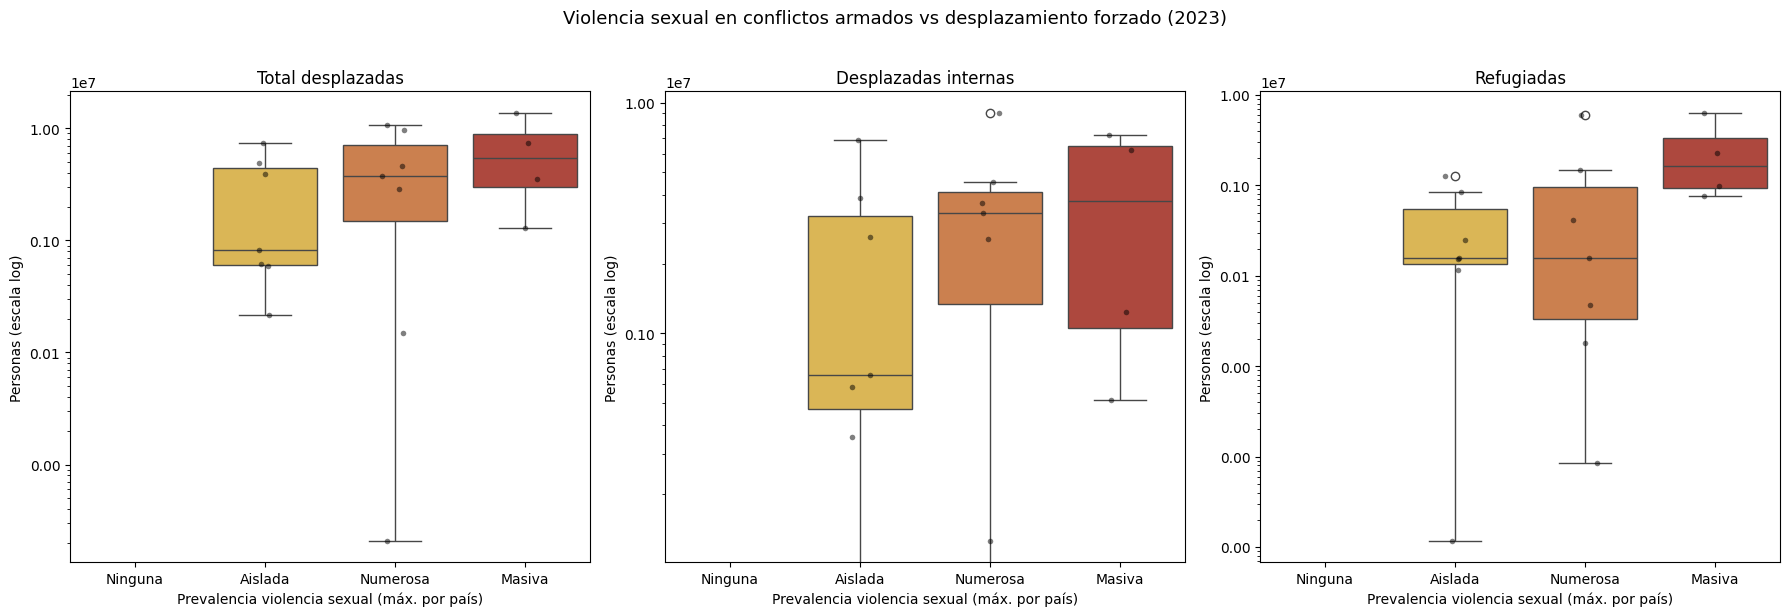

In [34]:
# Boxplots
orden_cats = ["Ninguna", "Aislada", "Numerosa", "Masiva"]
colores = ["#4caf93", "#f0c040", "#e07b3a", "#c0392b"]
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Violencia sexual en conflictos armados vs desplazamiento forzado (2023)",
    fontsize=13, y=1.02
)
 
variables = ["Total", "Desplazadas internas", "Refugiadas"]
titulos   = ["Total desplazadas", "Desplazadas internas", "Refugiadas"]
 
for ax, var, titulo in zip(axes, variables, titulos):
    sns.boxplot(
        data=df_merged_SVAC_ACNUR,
        x="Prevalencia EEUU (máx)",
        y=var,
        order=orden_cats,
        palette=colores,
        ax=ax,
        showfliers=True
    )
    # Superponer los puntos individuales para ver los países
    sns.stripplot(
        data=df_merged_SVAC_ACNUR,
        x="Prevalencia EEUU (máx)",
        y=var,
        order=orden_cats,
        color="black",
        alpha=0.5,
        size=4,
        ax=ax
    )
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_title(titulo)
    ax.set_xlabel("Prevalencia violencia sexual (máx. por país)")
    ax.set_ylabel("Personas (escala log)")
 
plt.tight_layout()
plt.show()

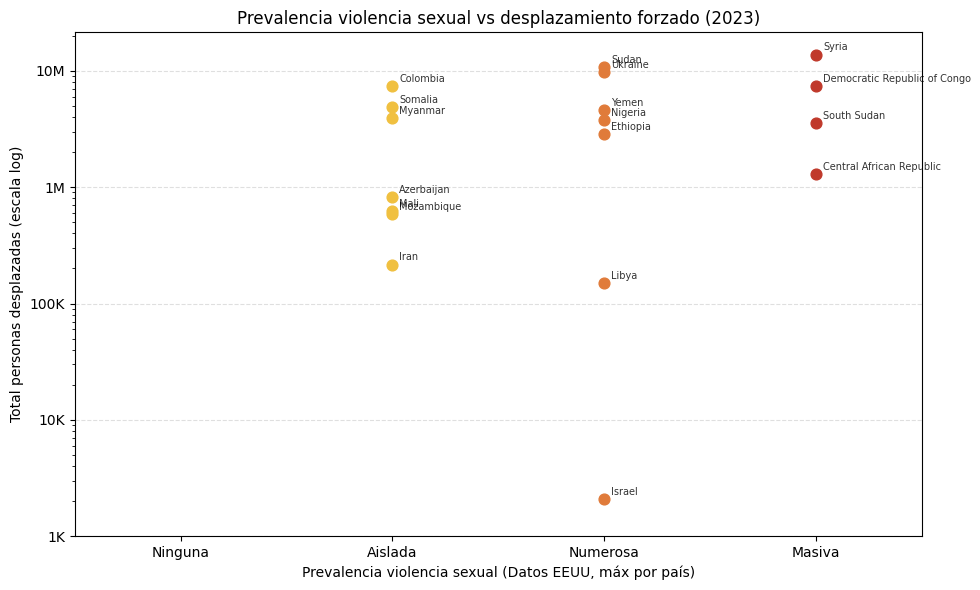

In [35]:
# Gráfica
fig2, ax2 = plt.subplots(figsize=(10, 6))

color_map = dict(zip(orden_cats, colores))
for _, row in df_merged_SVAC_ACNUR.iterrows():
    ax2.scatter(
        row["Datos EEUU numéricos"],
        row["Total"],
        color=color_map[row["Prevalencia EEUU (máx)"]],
        s=60,
        zorder=3
    )
    ax2.annotate(
        row["Ubicación"],
        (row["Datos EEUU numéricos"], row["Total"]),
        textcoords="offset points",
        xytext=(5, 3),
        fontsize=7,
        alpha=0.8
    )

ax2.set_yscale("log")
ax2.yaxis.set_major_formatter(FuncFormatter(
    lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K"
))
ax2.set_xticks([0, 1, 2, 3])
ax2.set_xticklabels(["Ninguna", "Aislada", "Numerosa", "Masiva"])
ax2.set_xlabel("Prevalencia violencia sexual (Datos EEUU, máx por país)")
ax2.set_ylabel("Total personas desplazadas (escala log)")
ax2.set_title(
    f"Prevalencia violencia sexual vs desplazamiento forzado (2023)",
)
ax2.set_xlim(-0.5, 3.5)
ax2.set_ylim(bottom=1e3)   # evita que el eje baje a 0 o negativos en escala log
ax2.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

interval columns not set, guessing: ['Total', 'Datos EEUU numéricos']


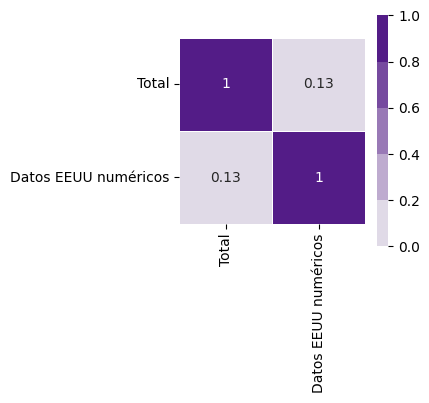

In [36]:
import phik

phik_matrix = df_merged_SVAC_ACNUR[["Total", "Datos EEUU numéricos"]].phik_matrix()

plt.figure(figsize=(3, 3))
sns.heatmap(phik_matrix,
            vmin=0,
            vmax=1,
            center=0,
            cmap=sns.diverging_palette(145, 280, s=85, l=25, n=10),
            square=True,
            annot=True,
            linewidths=.5)
plt.show()